# B5 — Parameter Estimation

**Reference:** W&H: Forecast Distributions; Illustrations and Extensions of Standard DLMs; Petris: Model Specification

**Concepts introduced:**
- V and W are rarely known in practice — we must estimate them from data
- MLE via `scipy.optimize.minimize` on the Kalman filter log-likelihood
- 2D likelihood surface — the ridge shaped by identifiability
- Bayesian estimation with PyMC (blackbox likelihood via `as_op`)
- Comparing MLE point estimate to posterior uncertainty

In [1]:
import sys
from pathlib import Path
project_root = Path().resolve().parents[1]
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from engine.models import make_local_level
from engine.filter import kalman_filter
from engine.simulate import simulate

## 1. The estimation problem

In the local level model, $V$ and $W$ are unknown. We need to estimate them.

**Two approaches:**

| Approach | Tool | Returns |
|----------|------|---------|
| **MLE** | `scipy.optimize.minimize` | point estimate $(\hat V, \hat W)$ |
| **Bayesian** | PyMC + Kalman blackbox likelihood | full posterior $p(V, W \mid y)$ |

Both use the `.loglik` attribute of the `FilterResult` returned by `kalman_filter(spec, y)` as the objective / likelihood.

In [2]:
# Simulate data
V_true, W_true = 2.0, 0.5
spec_true = make_local_level(V=V_true, W_level=W_true)
sim = simulate(spec_true, n=100, seed=0)
y = sim.y    # (100, 1)

## 2. MLE via scipy.optimize

We maximise $\log p(y \mid V, W)$ by minimising its negation.

**Log-space parameterisation:** we optimise $\log V$ and $\log W$ instead of
$V$ and $W$ directly. This enforces positivity and improves numerical conditioning —
$\log V$ ranges over all of $\mathbb R$ while $V > 0$.

In [3]:
def neg_loglik(params: np.ndarray) -> float:
    V_opt, W_opt = np.exp(params)
    spec = make_local_level(V=V_opt, W_level=W_opt)
    return -kalman_filter(spec, y).loglik

result = minimize(neg_loglik, x0=np.array([0.0, 0.0]), method="Nelder-Mead",
                  options={"xatol": 1e-6, "fatol": 1e-6, "maxiter": 2000})
V_mle, W_mle = np.exp(result.x)

print(f"Converged: {result.success}")
print(f"V_mle = {V_mle:.4f}  (true: {V_true})")
print(f"W_mle = {W_mle:.4f}  (true: {W_true})")
print(f"\u03ba_mle = W/V = {W_mle/V_mle:.4f}  (true: {W_true/V_true:.4f})")

Converged: True
V_mle = 1.4742  (true: 2.0)
W_mle = 0.6032  (true: 0.5)
κ_mle = W/V = 0.4091  (true: 0.2500)


## 3. Likelihood surface

The 2D likelihood surface $\log p(y \mid V, W)$ has a characteristic **ridge**
shape: many (V, W) pairs with the same ratio $W/V$ give nearly identical likelihoods.
This reflects partial non-identifiability — only the ratio is well-determined from
a single series of modest length.

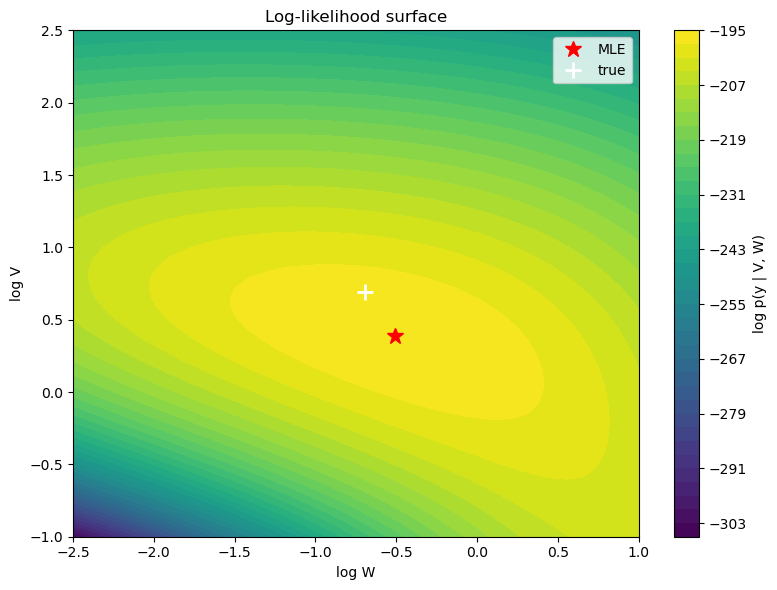

In [4]:
V_grid = np.exp(np.linspace(-1, 2.5, 50))
W_grid = np.exp(np.linspace(-2.5, 1, 50))
LL = np.zeros((len(V_grid), len(W_grid)))

for i, V_try in enumerate(V_grid):
    for j, W_try in enumerate(W_grid):
        sp = make_local_level(V=V_try, W_level=W_try)
        LL[i, j] = kalman_filter(sp, y).loglik

fig, ax = plt.subplots(figsize=(8, 6))
cf = ax.contourf(np.log(W_grid), np.log(V_grid), LL, levels=40, cmap="viridis")
fig.colorbar(cf, ax=ax, label="log p(y | V, W)")
ax.plot(np.log(W_mle), np.log(V_mle), "r*", ms=12, label="MLE")
ax.plot(np.log(W_true), np.log(V_true), "w+", ms=12, mew=2, label="true")
ax.set(xlabel="log W", ylabel="log V", title="Log-likelihood surface")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Bayesian estimation with PyMC

The Kalman filter is pure NumPy — PyTensor (PyMC's backend) cannot differentiate
through it. We register the log-likelihood function as a **blackbox op** via
`pytensor.compile.ops.as_op`. This tells PyMC to use the **Slice sampler**
(gradient-free) instead of NUTS (requires gradients).

**Note:** The Slice sampler is less efficient than NUTS for smooth posteriors but
works correctly here. For production use, consider implementing the filter in
PyTensor for NUTS compatibility.

In [5]:
HAS_PYMC = False
try:
    import pymc as pm
    import pytensor.tensor as pt
    import pytensor.compile.ops as ops
    import arviz as az
    HAS_PYMC = True
except ImportError:
    print("PyMC not installed \u2014 skipping Bayesian estimation cells")

if HAS_PYMC:
    @ops.as_op(itypes=[pt.dscalar, pt.dscalar], otypes=[pt.dscalar])
    def kalman_loglik_op(V_val: np.ndarray, W_val: np.ndarray) -> np.ndarray:
        spec = make_local_level(V=float(V_val), W_level=float(W_val))
        return np.array(kalman_filter(spec, y).loglik)

    with pm.Model() as dlm_model:
        V_rv = pm.HalfNormal("V", sigma=3.0)
        W_rv = pm.HalfNormal("W", sigma=1.0)
        _    = pm.Potential("loglik", kalman_loglik_op(V_rv, W_rv))
        idata = pm.sample(500, tune=500, progressbar=False, random_seed=42)

    print(az.summary(idata, var_names=["V", "W"]))

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


/var/folders/f4/lq_nbljd085dj7ngdyn8nzvw0000gn/T/ipykernel_86821/1957560658.py:12: FutureWarning: pytensor.as_op is deprecated and will be removed in a future release. Please use pytensor.wrap_py instead.
  @ops.as_op(itypes=[pt.dscalar, pt.dscalar], otypes=[pt.dscalar])


Multiprocess sampling (4 chains in 4 jobs)


CompoundStep


>Slice: [V]


>Slice: [W]


Sampling 4 chains for 500 tune and 500 draw iterations (2_000 + 2_000 draws total) took 65 seconds.


    mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
V  1.530  0.334   0.904    2.133      0.009    0.007    1338.0    1135.0   
W  0.669  0.249   0.267    1.158      0.007    0.006    1176.0    1419.0   

   r_hat  
V    1.0  
W    1.0  


The plot below shows the full posterior distribution for $V$ and $W$, overlaid
with the MLE point estimate (dashed red) and the true value (solid black).

**What to look for:**
- Is the true value inside the bulk of the posterior?
- How wide is each posterior? Width reflects how much information the data carry.
- The MLE should sit near the posterior mode for weakly informative priors.

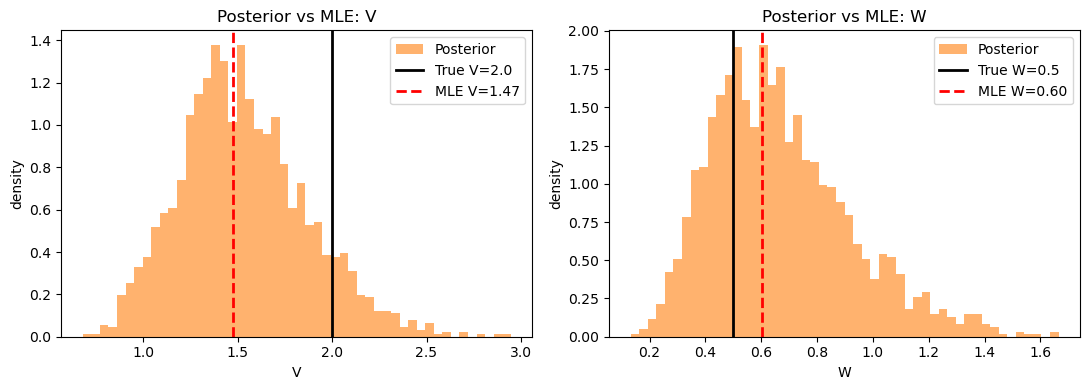

In [6]:
if HAS_PYMC:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    for ax, var, true_val, mle_val in zip(
        axes,
        ["V", "W"],
        [V_true, W_true],
        [V_mle, W_mle],
    ):
        samples = idata.posterior[var].values.ravel()
        ax.hist(samples, bins=50, density=True, alpha=0.6, color="C1", label="Posterior")
        ax.axvline(true_val, color="k", ls="-",  lw=2, label=f"True {var}={true_val}")
        ax.axvline(mle_val,  color="r", ls="--", lw=2, label=f"MLE {var}={mle_val:.2f}")
        ax.set(xlabel=var, ylabel="density", title=f"Posterior vs MLE: {var}")
        ax.legend()
    plt.tight_layout()
    plt.show()

## Exercises

**Exercise 1** — Simulate a short series (T=20) and a long series (T=200) with
the same V=2.0, W=0.5. Run MLE on both. How does estimation error change with T?

**Exercise 2** *(requires PyMC; skip if unavailable)* — Replace `HalfNormal` priors
with `pm.Exponential("V", lam=0.5)` and `pm.Exponential("W", lam=1.0)`. Re-run.
How does the posterior change, especially for the short T=20 series?

**Exercise 3** — Plot the likelihood profile over V with W fixed at W_mle
(a 1D slice of the surface). Mark the MLE and the posterior mean. Are they close?

True: V=2.0, W=0.5
T=20:  V_mle=1.7069  W_mle=0.0000  |ΔV|=0.2931  |ΔW|=0.5000
T=200: V_mle=1.9325  W_mle=0.1609  |ΔV|=0.0675  |ΔW|=0.3391

Estimation error decreases with T — more data → MLE closer to truth


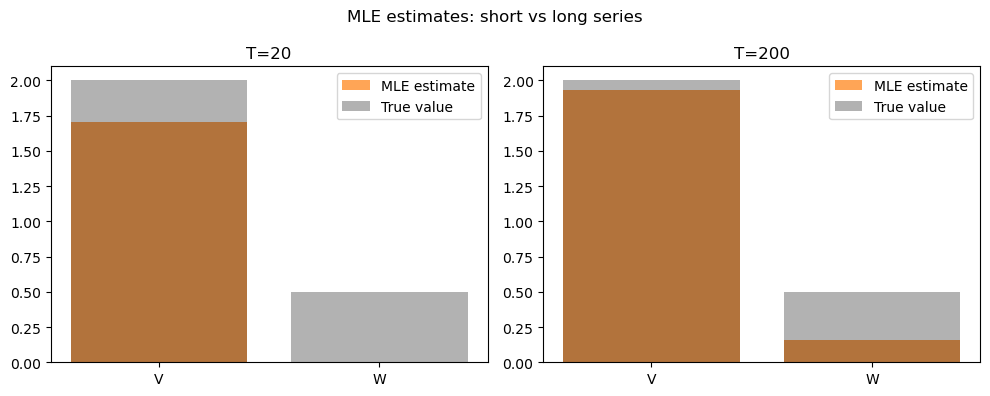

In [7]:
# Exercise 1 — Short (T=20) vs long (T=200) series: estimation error vs sample size

def run_mle(T_size, seed=0):
    spec_gen = make_local_level(V=2.0, W_level=0.5)
    sim_t = simulate(spec_gen, n=T_size, seed=seed)
    y_t = sim_t.y

    def neg_ll(params):
        V_opt = max(np.exp(params[0]), 1e-6)
        W_opt = max(np.exp(params[1]), 1e-6)
        sp = make_local_level(V=V_opt, W_level=W_opt)
        return -kalman_filter(sp, y_t).loglik

    res = minimize(neg_ll, x0=np.array([0.0, 0.0]), method='Nelder-Mead',
                   options={'xatol': 1e-6, 'fatol': 1e-6, 'maxiter': 2000})
    V_hat, W_hat = max(np.exp(res.x[0]), 1e-6), max(np.exp(res.x[1]), 1e-6)
    return V_hat, W_hat

V_hat_20,  W_hat_20  = run_mle(20,  seed=1)
V_hat_200, W_hat_200 = run_mle(200, seed=1)

print('True: V=2.0, W=0.5')
print(f'T=20:  V_mle={V_hat_20:.4f}  W_mle={W_hat_20:.4f}  '
      f'|ΔV|={abs(V_hat_20 - 2.0):.4f}  |ΔW|={abs(W_hat_20 - 0.5):.4f}')
print(f'T=200: V_mle={V_hat_200:.4f}  W_mle={W_hat_200:.4f}  '
      f'|ΔV|={abs(V_hat_200 - 2.0):.4f}  |ΔW|={abs(W_hat_200 - 0.5):.4f}')
print()
print('Estimation error decreases with T — more data → MLE closer to truth')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, T_s, V_h, W_h in zip(axes, [20, 200], [V_hat_20, V_hat_200], [W_hat_20, W_hat_200]):
    ax.bar(['V', 'W'], [V_h, W_h], color='C1', alpha=0.7, label='MLE estimate')
    ax.bar(['V', 'W'], [2.0, 0.5], color='k', alpha=0.3, label='True value')
    ax.set_title(f'T={T_s}'); ax.legend()
plt.suptitle('MLE estimates: short vs long series')
plt.tight_layout()
plt.show()


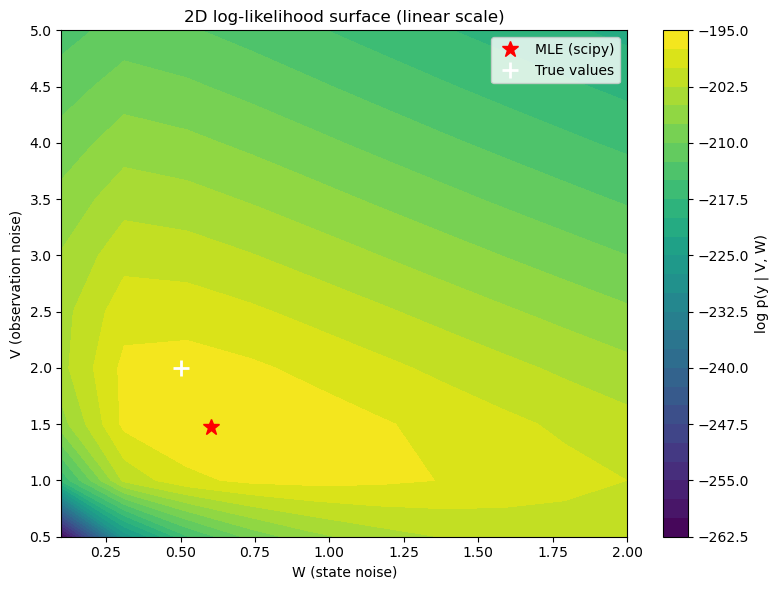

Best V on grid: 1.50  (true: 2.0)
Best W on grid: 0.52  (true: 0.5)
Ridge shape: many (V, W) pairs with similar ratio give near-equal likelihoods


In [8]:
# Exercise 2 — Grid search over V and W jointly; show 2D log-likelihood surface
V_grid_ex = np.linspace(0.5, 5, 10)
W_grid_ex = np.linspace(0.1, 2, 10)
LL_ex = np.zeros((len(V_grid_ex), len(W_grid_ex)))

for i, V_try in enumerate(V_grid_ex):
    for j, W_try in enumerate(W_grid_ex):
        sp = make_local_level(V=V_try, W_level=W_try)
        LL_ex[i, j] = kalman_filter(sp, y).loglik

fig, ax = plt.subplots(figsize=(8, 6))
cf = ax.contourf(W_grid_ex, V_grid_ex, LL_ex, levels=30, cmap='viridis')
fig.colorbar(cf, ax=ax, label='log p(y | V, W)')
ax.plot(W_mle, V_mle, 'r*', ms=12, label='MLE (scipy)')
ax.plot(W_true, V_true, 'w+', ms=12, mew=2, label='True values')
ax.set(xlabel='W (state noise)', ylabel='V (observation noise)',
       title='2D log-likelihood surface (linear scale)')
ax.legend()
plt.tight_layout()
plt.show()

# Find best grid point
best_i, best_j = np.unravel_index(np.argmax(LL_ex), LL_ex.shape)
print(f'Best V on grid: {V_grid_ex[best_i]:.2f}  (true: {V_true})')
print(f'Best W on grid: {W_grid_ex[best_j]:.2f}  (true: {W_true})')
print('Ridge shape: many (V, W) pairs with similar ratio give near-equal likelihoods')


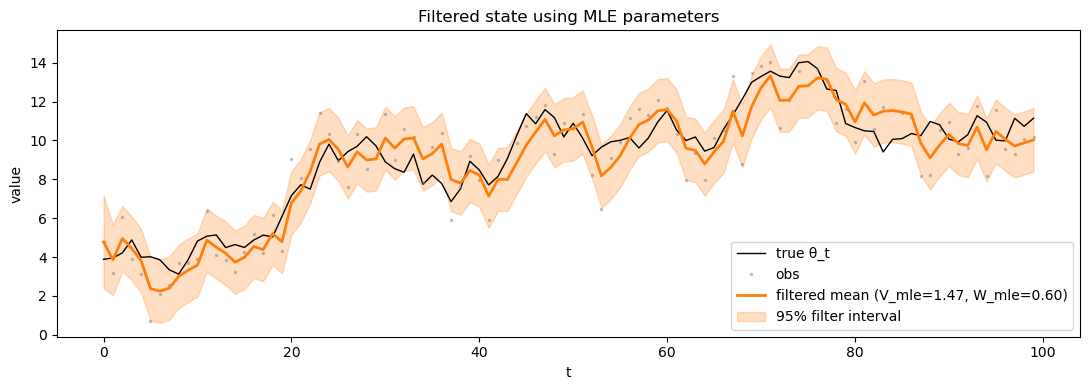

Coverage: 94.0% of true states inside 95% interval


In [9]:
# Exercise 3 — Run filter with MLE params, plot filtered state with 95% interval
spec_mle = make_local_level(V=V_mle, W_level=W_mle)
fr_mle   = kalman_filter(spec_mle, y)
std_mle  = np.sqrt(fr_mle.C[:, 0, 0])
t_arr    = np.arange(len(y))

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(t_arr, sim.theta_true[:, 0], 'k-', lw=1, label='true θ_t')
ax.plot(t_arr, y[:, 0], '.', ms=3, alpha=0.4, color='grey', label='obs')
ax.plot(t_arr, fr_mle.m[:, 0], 'C1-', lw=2,
        label=f'filtered mean (V_mle={V_mle:.2f}, W_mle={W_mle:.2f})')
ax.fill_between(t_arr,
                fr_mle.m[:, 0] - 1.96*std_mle,
                fr_mle.m[:, 0] + 1.96*std_mle,
                alpha=0.25, color='C1', label='95% filter interval')
ax.set(xlabel='t', ylabel='value',
       title='Filtered state using MLE parameters')
ax.legend()
plt.tight_layout()
plt.show()

# What fraction of true states fall within the 95% interval?
in_interval = ((sim.theta_true[:, 0] >= fr_mle.m[:, 0] - 1.96*std_mle) &
               (sim.theta_true[:, 0] <= fr_mle.m[:, 0] + 1.96*std_mle))
print(f'Coverage: {in_interval.mean()*100:.1f}% of true states inside 95% interval')
